**Assignment 7 — Regularized Regression Models**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X.shape, y.shape

((768, 8), (768,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lin = LinearRegression()
lin.fit(X_train, y_train)

pred_lin = lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
r2_lin = r2_score(y_test, pred_lin)

rmse_lin, r2_lin

(np.float64(0.4135761995189049), 0.25500281176741757)

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

rmse_ridge, r2_ridge

(np.float64(0.41352928512472564), 0.2551718210548829)

In [ ]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

rmse_lasso,


(np.float64(0.4125353784827947), 0.25874786786691617)

In [ ]:
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_test)

rmse_elastic = np.sqrt(mean_squared_error(y_test, pred_elastic))
r2_elastic = r2_score(y_test, pred_elastic)

rmse_elastic, r2_elastic

(np.float64(0.41249573946759976), 0.2588903094340288)

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lin.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'ElasticNet': elastic.coef_
})

coef_df

,Feature,Linear,Ridge,Lasso,ElasticNet
0,Pregnancies,0.034656,0.034681,0.028758,0.031900
1,Glucose,0.180323,0.179989,0.167667,0.172316
2,BloodPressure,-0.042193,-0.042015,-0.024425,-0.032367
3,SkinThickness,0.008206,0.008131,0.000000,0.000000
4,Insulin,-0.032304,-0.032086,-0.013087,-0.020515
5,BMI,0.116314,0.116137,0.105269,0.111455
6,DiabetesPedigreeFunction,0.037448,0.037430,0.028323,0.033216
7,Age,0.074255,0.074168,0.066531,0.069638


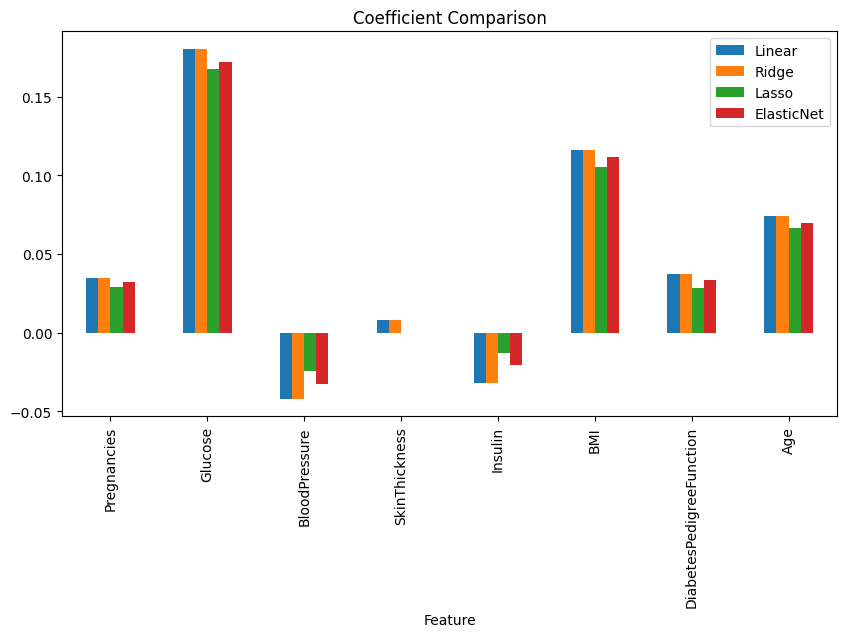

In [ ]:
coef_df.set_index('Feature').plot(kind='bar', figsize=(10,5))
plt.title("Coefficient Comparison")
plt.show()

**Conclusion:** Regularization techniques like Ridge, Lasso, and ElasticNet improve model performance by reducing overfitting. They control coefficient values and help in better generalization compared to Linear Regression.